In [1]:
# ===== CHARGER DONNEES =====

import json

# Charger les exigences OpenAI
with open("srs_history_openai.json", "r", encoding="utf-8") as f:
    openai_generated_srs = json.load(f)

# Charger les exigences Gemini
with open("srs_history_gemini.json", "r", encoding="utf-8") as f:
    gemini_generated_srs = json.load(f)

# Exigences humaines
human_requirements = [
    "The system shall allow the administrator to create, modify, and delete teaching modules.",
    "The system shall allow one or more responsible teachers to be assigned to a module.",
    "The system shall allow the administrator to manage the database of teachers and students.",
    "A responsible teacher shall be able to add teachers or students to a module if they are already registered in the database.",
    "A teacher shall be able to record the absence of a student in a module.",
    "When recording an absence, a teacher shall be able to add a comment.",
    "A teacher shall be able to view the list of absences for students enrolled in their modules.",
    "Administrative staff shall be able to record the reason for an absence.",
    "Administrative staff shall be able to view all student absences.",
    "The system shall allow absences to be grouped by module or by student.",
    "The system shall alert teachers when a student has more than three unjustified absences.",
    "The system shall be accessible through a web browser.",
    "The system shall distinguish between roles: administrator, teacher, and administrative staff.",
    "Access to system functionalities shall be restricted according to the user’s role."
]

print("Loaded human requirements:", len(human_requirements))
print("Loaded openai_generated_srs:", len(openai_generated_srs))
print("Loaded gemini_generated_srs:", len(gemini_generated_srs))

Loaded human requirements: 14
Loaded openai_generated_srs: 10
Loaded gemini_generated_srs: 1


In [2]:
# ===== NETTOYAGEE DE DONNEES =====

import re


def extract_requirements_clean(text):
    reqs = []

    if not isinstance(text, str):
        return reqs

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        line = re.sub(r"^Requirement\s+\d+\s*:\s*", "", line, flags=re.IGNORECASE)
        reqs.append(line)

    return reqs


def normalize(text):
    return text.lower().strip()


openai_generated_srs_cleaned = [extract_requirements_clean(gen["requirements"]) for gen in openai_generated_srs]
gemini_generated_srs_cleaned = [extract_requirements_clean(gen["requirements"]) for gen in gemini_generated_srs]

human_requirements = [normalize(r) for r in human_requirements]
openai_generated_srs_cleaned = [[normalize(r) for r in gen] for gen in openai_generated_srs_cleaned]
gemini_generated_srs_cleaned = [[normalize(r) for r in gen] for gen in gemini_generated_srs_cleaned]

# Exemple
print("Example cleaned openai SRS:")
for r in openai_generated_srs_cleaned[0][:3]:
    print("-", r)

print("\nExample cleaned gemini SRS:")
for r in gemini_generated_srs_cleaned[0][:3]:
    print("-", r)

Example cleaned openai SRS:
- implement role-based authentication and authorization for at least these roles: administrator, referring teacher, teacher, administrative staff, and student.
- allow the administrator to create, edit, and delete teaching modules.
- allow the administrator to associate one or more referring teachers with a teaching module and to modify those associations.

Example cleaned gemini SRS:
- the administrator shall create, update, and delete teaching modules.
- the administrator shall associate teaching modules with one or more referring teachers.
- the administrator shall manage the global database of teachers and students.


In [3]:
# ===== CHARGER LES MODELES =====

%pip install sentence-transformers

import os
import json
import time
import urllib.request
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

load_dotenv()

ollama_base_url = os.environ.get("OLLAMA_BASE_URL", "http://127.0.0.1:11434")
ollama_model = os.environ.get("OLLAMA_MODEL", "llama3.2:1b")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ===== FONCTIONS METRICS =====

def completeness_score(ai_reqs, human_reqs, threshold=0.7):
    ai_emb = embedding_model.encode(ai_reqs)
    human_emb = embedding_model.encode(human_reqs)
    sim_matrix = cosine_similarity(ai_emb, human_emb)
    matched_human = (sim_matrix >= threshold).any(axis=0).sum()
    return matched_human / len(human_reqs)


def _extract_json_object(text):
    if isinstance(text, dict):
        return text

    cleaned = text.strip()
    first = cleaned.find("{")
    last = cleaned.rfind("}")

    if first == -1 or last == -1:
        raise ValueError(f"Ollama did not return JSON: {text[:200]}")

    return json.loads(cleaned[first:last + 1])


def _call_ollama_json(prompt, max_retries=3):
    payload = {
        "model": ollama_model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "format": "json",
    }
    data = json.dumps(payload).encode("utf-8")
    request = urllib.request.Request(
        f"{ollama_base_url}/api/chat",
        data=data,
        headers={"Content-Type": "application/json"},
        method="POST",
    )

    for attempt in range(max_retries):
        try:
            with urllib.request.urlopen(request, timeout=120) as response:
                response_data = json.loads(response.read().decode("utf-8"))
            content = response_data["message"]["content"]
            return _extract_json_object(content)
        except Exception:
            if attempt == max_retries - 1:
                raise
            time.sleep(2 ** attempt)


def _build_metric_prompt(metric_name, generated_requirements, human_requirements=None):
    generated_json = json.dumps(generated_requirements, ensure_ascii=False, indent=2)
    human_json = json.dumps(human_requirements or [], ensure_ascii=False, indent=2)

    if metric_name == "precision":
        return f"""
You are evaluating PRECISION for generated software requirements.

Reference requirements:
{human_json}

Generated requirements:
{generated_json}

For each generated requirement, decide whether it is correct and aligned with the reference requirements.
A requirement is correct if it is relevant, faithful, and does not introduce a wrong or unsupported statement.

Return only valid JSON with this exact structure:
{{
  "metric": "precision",
  "items": [
    {{
      "index": 1,
      "requirement": "...",
      "is_correct": true,
      "reason": "short explanation"
    }}
  ]
}}

Do not add markdown, comments, or extra text.
""".strip()

    if metric_name == "novelty":
        return f"""
You are evaluating NOVELTY for generated software requirements.

Reference requirements:
{human_json}

Generated requirements:
{generated_json}

For each generated requirement, decide whether it introduces meaningful new information not already covered by the reference requirements.
A requirement is novel if it is not a simple rewording of an existing reference requirement.

Return only valid JSON with this exact structure:
{{
  "metric": "novelty",
  "items": [
    {{
      "index": 1,
      "requirement": "...",
      "is_novel": true,
      "reason": "short explanation"
    }}
  ]
}}

Do not add markdown, comments, or extra text.
""".strip()

    if metric_name == "redundancy":
        return f"""
You are evaluating REDUNDANCY within a set of generated software requirements.

Generated requirements:
{generated_json}

For each generated requirement, decide whether it is redundant because it repeats, restates, or overlaps heavily with another requirement in the same generated list.
Mark a requirement as redundant if it adds no distinct meaning.

Return only valid JSON with this exact structure:
{{
  "metric": "redundancy",
  "items": [
    {{
      "index": 1,
      "requirement": "...",
      "is_redundant": false,
      "duplicate_of": [2, 5],
      "reason": "short explanation"
    }}
  ]
}}

If a requirement is not redundant, use an empty list for duplicate_of.
Do not add markdown, comments, or extra text.
""".strip()

    if metric_name == "testability":
        return f"""
You are evaluating TESTABILITY for generated software requirements.

Generated requirements:
{generated_json}

For each generated requirement, decide whether it is testable.
A requirement is testable if it is specific, observable, and can be verified with a clear pass/fail check.

Return only valid JSON with this exact structure:
{{
  "metric": "testability",
  "items": [
    {{
      "index": 1,
      "requirement": "...",
      "is_testable": true,
      "reason": "short explanation"
    }}
  ]
}}

Do not add markdown, comments, or extra text.
""".strip()

    raise ValueError(f"Unknown metric: {metric_name}")


def evaluate_metric_with_ollama(metric_name, generated_requirements, human_requirements=None):
    prompt = _build_metric_prompt(metric_name, generated_requirements, human_requirements)
    return _call_ollama_json(prompt)


def summarize_metric_items(items, boolean_key):
    if not items:
        return 0.0

    positives = sum(1 for item in items if item.get(boolean_key))
    return positives / len(items)

In [14]:
# ===== EVALUATION =====

def evaluate_generations(all_gens, label):
    results = []
    detailed_results = []

    for i, gen in enumerate(all_gens):
        completeness = completeness_score(gen, human_requirements)
        precision_payload = evaluate_metric_with_ollama("precision", gen, human_requirements)
        novelty_payload = evaluate_metric_with_ollama("novelty", gen, human_requirements)
        redundancy_payload = evaluate_metric_with_ollama("redundancy", gen)
        testability_payload = evaluate_metric_with_ollama("testability", gen)

        precision = summarize_metric_items(precision_payload.get("items", []), "is_correct")
        novelty = summarize_metric_items(novelty_payload.get("items", []), "is_novel")
        redundancy = summarize_metric_items(redundancy_payload.get("items", []), "is_redundant")
        testability = summarize_metric_items(testability_payload.get("items", []), "is_testable")

        generation_name = f"{label}_{i + 1}"
        results.append({
            "Generation": generation_name,
            "Num_Requirements": len(gen),
            "Precision": round(precision, 2),
            "Completeness": round(completeness, 2),
            "Novelty": round(novelty, 2),
            "Redundancy": round(redundancy, 2),
            "Testability": round(testability, 2)
        })

        detailed_results.append({
            "Generation": generation_name,
            "Num_Requirements": len(gen),
            "Precision": precision_payload,
            "Completeness": completeness,
            "Novelty": novelty_payload,
            "Redundancy": redundancy_payload,
            "Testability": testability_payload
        })

    return results, detailed_results


results_openai, details_openai = evaluate_generations(openai_generated_srs_cleaned, "openai")
results_gemini, details_gemini = evaluate_generations(gemini_generated_srs_cleaned, "gemini")

all_results = results_openai + results_gemini
all_details = details_openai + details_gemini

import pandas as pd
df = pd.DataFrame(all_results)
df

with open("ollama_metric_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(all_details, f, indent=4, ensure_ascii=False)

print("Saved detailed metric evaluations to ollama_metric_evaluation.json")

KeyboardInterrupt: 

In [15]:
# ===== BEST GENERATION =====

best = df.sort_values(
    ["Completeness", "Precision", "Novelty", "Redundancy"],
    ascending=[False, False, False, True]
).iloc[0]

print("Best generation overall:", best["Generation"])
print("\nMetrics:")
print(best)

NameError: name 'df' is not defined

In [ ]:
# ===== NOUVEAUX EXIGENCES =====

def get_novel_requirements(ai_reqs, human_reqs, threshold=0.7):
    ai_emb = embedding_model.encode(ai_reqs)
    human_emb = embedding_model.encode(human_reqs)

    sim_matrix = cosine_similarity(ai_emb, human_emb)

    novel = []
    for i, req in enumerate(ai_reqs):
        if not (sim_matrix[i] >= threshold).any():
            novel.append(req)
    return novel


novel_openai = get_novel_requirements(openai_generated_srs_cleaned[0], human_requirements)
novel_gemini = get_novel_requirements(gemini_generated_srs_cleaned[0], human_requirements)

print("Novel requirements discovered in openai_generated_srs:\n", novel_openai)
print("\nNovel requirements discovered in gemini_generated_srs:\n", novel_gemini)

Novel requirements discovered in simple_generated_srs:
 ['record metadata for each absence entry: reporter (user who recorded it), date/time, module, student, comment, and current justification status.', 'support filtering and reporting based on absence justification status (e.g., justified, unjustified, pending).']

Novel requirements discovered in extended_generated_srs:
 ['the system shall provide secure user authentication for all roles (administrator, referring teacher, teacher, student, administrative staff).', 'the administrator shall be able to create, edit, deactivate, reactivate, and delete user accounts for all roles.', 'the system shall require unique identifiers for each user (e.g., student id, teacher id) and shall prevent duplicate user accounts.', 'the system shall allow administrators to import and export users in bulk via common formats (csv, xlsx) with validation and error reporting.', 'the system shall allow administrators to assign one or more roles to a user and t

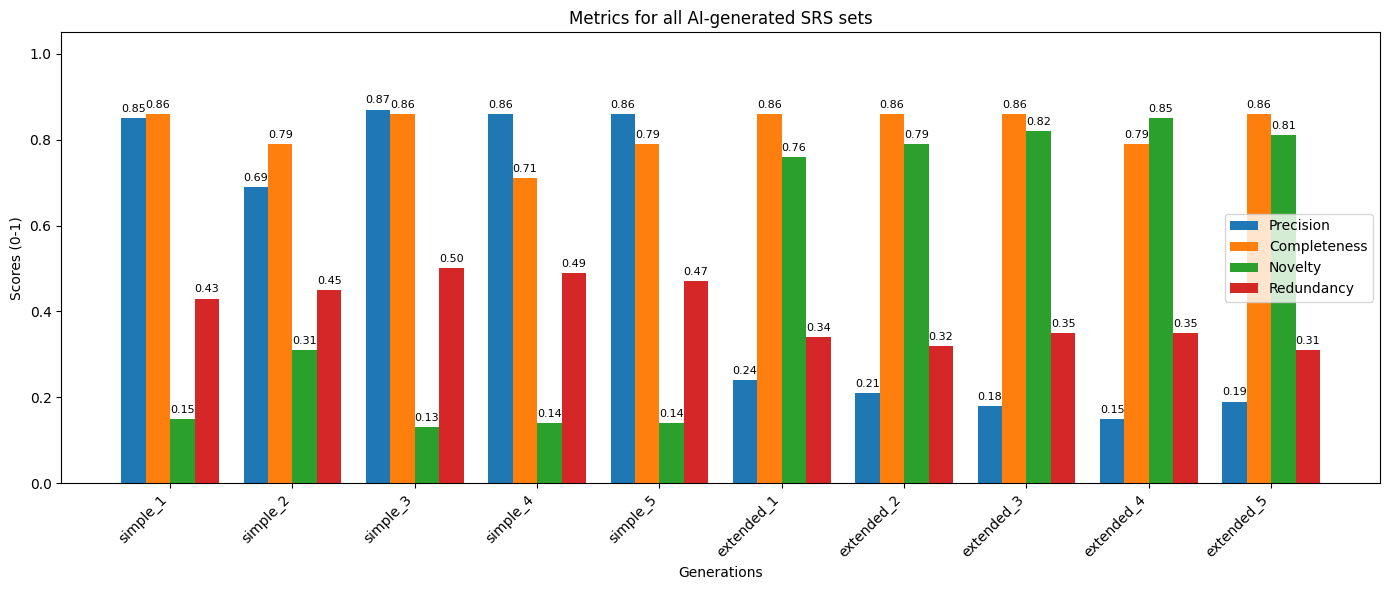

In [ ]:
# ===== PLOT PAR METRIQUE =====

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision", "Completeness", "Novelty", "Redundancy", "Testability"]
plot_data = {metric: (df.loc[df["Generation"].str.startswith("openai"), metric].tolist(),
                      df.loc[df["Generation"].str.startswith("gemini"), metric].tolist())
             for metric in metrics}

for metric in metrics:
    openai_scores, gemini_scores = plot_data[metric]
    labels = [f"OpenAI\n(n={len(openai_scores)})", f"Gemini\n(n={len(gemini_scores)})"]
    values = [openai_scores, gemini_scores]

    plt.figure(figsize=(7, 5))
    plt.bar(labels, [np.mean(v) if v else 0 for v in values], color=["#1f77b4", "#ff7f0e"])
    plt.ylim(0, 1.05)
    plt.ylabel("Score (0-1)")
    plt.title(f"{metric} comparison by source")
    plt.grid(axis="y", alpha=0.3)

    for idx, v in enumerate(values):
        score = np.mean(v) if v else 0
        plt.text(idx, score + 0.02, f"{score:.2f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# Box plot de comparaison OpenAI vs Gemini pour chaque métrique
fig, axes = plt.subplots(1, len(metrics), figsize=(22, 5), sharey=True)

for ax, metric in zip(axes, metrics):
    openai_scores, gemini_scores = plot_data[metric]
    ax.boxplot([openai_scores, gemini_scores], labels=["OpenAI", "Gemini"], patch_artist=True,
               boxprops=dict(facecolor="#d9e8fb"), medianprops=dict(color="black"))
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("OpenAI vs Gemini SRS comparison by metric", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ===== METRICS TESTABILITY =====

def testability_score(requirement):
    payload = evaluate_metric_with_ollama("testability", [requirement])
    items = payload.get("items", [])
    if not items:
        return 0.0
    return 1.0 if items[0].get("is_testable") else 0.0


def evaluate_testability(requirements):
    payload = evaluate_metric_with_ollama("testability", requirements)
    return summarize_metric_items(payload.get("items", []), "is_testable")

In [ ]:
# ===== APPLY TESTABILITY =====

test_results = [
    {
        "Generation": row["Generation"],
        "Testability": row["Testability"]
    }
    for row in all_results
]

import pandas as pd
test_df = pd.DataFrame(test_results)
test_df

,Generation,Testability
0,simple_1,0.41
1,simple_2,0.46
2,simple_3,0.71
3,simple_4,0.43
4,simple_5,0.43
5,extended_1,0.63
6,extended_2,0.62
7,extended_3,0.65
8,extended_4,0.64
9,extended_5,0.58


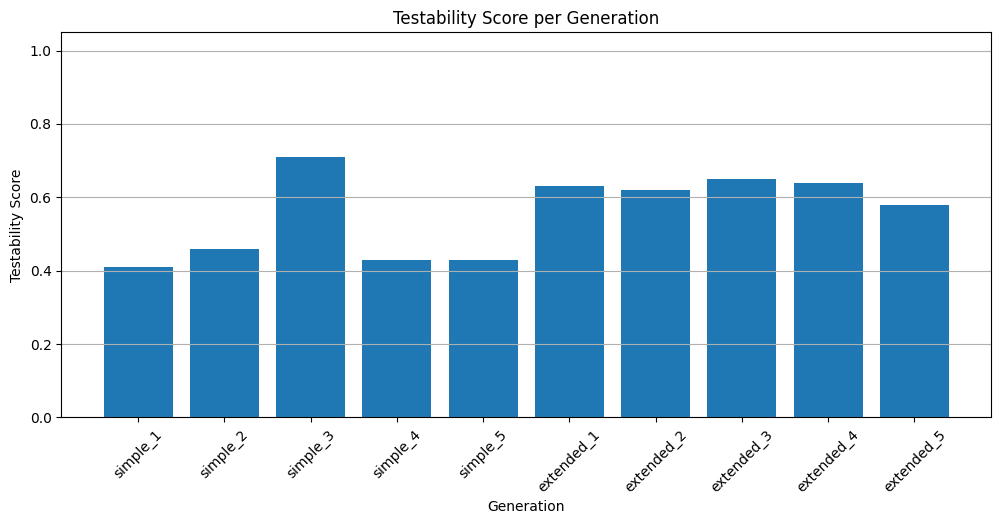

In [ ]:
# ===== TESTABILITY VISUALIZATION =====

import matplotlib.pyplot as plt

labels = [r["Generation"] for r in test_results]
scores = [r["Testability"] for r in test_results]

plt.figure(figsize=(12,5))
plt.bar(labels, scores)
plt.xticks(rotation=45)
plt.ylim(0,1.05)

plt.title("Testability Score per Generation")
plt.xlabel("Generation")
plt.ylabel("Testability Score")

plt.grid(axis='y')
plt.show()

In [ ]:
# ===== IMPROVED TESTABILITY =====

def compute_final_testability(testability, precision, completeness, redundancy):

    final_score = (
        0.35 * testability +
        0.30 * precision +
        0.20 * (1 - redundancy) +
        0.15 * completeness
    )

    return round(final_score, 3)

In [ ]:
# ===== APPLY FINAL TESTABILITY =====

final_results = []

for i, row in df.iterrows():

    gen_name = row["Generation"]

    # Find testability score
    test_score = test_df[test_df["Generation"] == gen_name]["Testability"].values[0]

    final_score = compute_final_testability(
        test_score,
        row["Precision"],
        row["Completeness"],
        row["Redundancy"]
    )

    final_results.append({
        "Generation": gen_name,
        "Final_Testability": final_score
    })

final_df = pd.DataFrame(final_results)
final_df

,Generation,Final_Testability
0,simple_1,0.641
1,simple_2,0.597
2,simple_3,0.738
3,simple_4,0.617
4,simple_5,0.633
5,extended_1,0.553
6,extended_2,0.545
7,extended_3,0.541
8,extended_4,0.518
9,extended_5,0.527


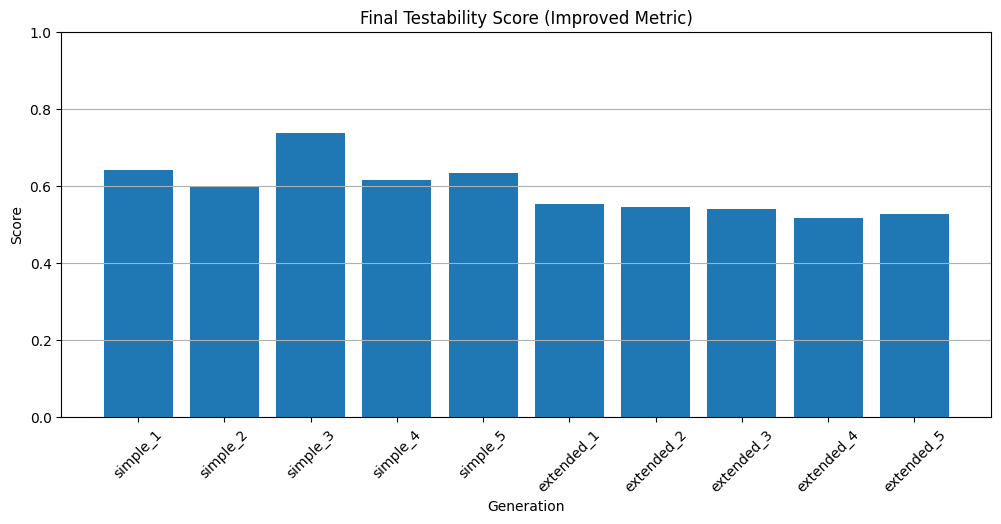

In [ ]:
# ===== FINAL COMPARISON CHART =====

import matplotlib.pyplot as plt

labels = final_df["Generation"]
scores = final_df["Final_Testability"]

plt.figure(figsize=(12,5))
plt.bar(labels, scores)
plt.xticks(rotation=45)
plt.ylim(0,1)

plt.title("Final Testability Score (Improved Metric)")
plt.xlabel("Generation")
plt.ylabel("Score")

plt.grid(axis='y')
plt.show()